In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://raw.githubusercontent.com/andhikaw789/Customer-Personality-Analysis/main/marketing_campaign.csv'
df = pd.read_csv(url, sep='\t')

print(df.shape)
df.head()

(2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [2]:
df.info()
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [3]:
# Drop rows with missing Income (only 24 out of 2240 — negligible)
df = df.dropna(subset=['Income'])

# Drop columns that don't help clustering
df = df.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue'])

print(df.shape)

(2216, 26)


In [4]:
df['Age'] = 2024 - df['Year_Birth']

df['Total_Spending'] = df[['MntWines','MntFruits','MntMeatProducts',
                            'MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)

df['Total_Purchases'] = df[['NumDealsPurchases','NumWebPurchases',
                             'NumCatalogPurchases','NumStorePurchases']].sum(axis=1)

df['Total_Children'] = df['Kidhome'] + df['Teenhome']

df['Customer_Since'] = (pd.to_datetime('2024-01-01') - pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')).dt.days

print(df[['Age','Total_Spending','Total_Purchases','Total_Children','Customer_Since']].head())

   Age  Total_Spending  Total_Purchases  Total_Children  Customer_Since
0   67            1617               25               0            4136
1   70              27                6               2            3586
2   59             776               21               0            3785
3   40              53                8               1            3612
4   43             422               19               1            3634


In [5]:
# Simplify Marital_Status
df['Marital_Status'] = df['Marital_Status'].replace({
    'Married':'Partner', 'Together':'Partner',
    'Single':'Alone', 'Divorced':'Alone', 'Widow':'Alone',
    'Alone':'Alone', 'Absurd':'Alone', 'YOLO':'Alone'
})

# Simplify Education
df['Education'] = df['Education'].replace({
    '2n Cycle':'Postgraduate', 'Master':'Postgraduate', 'PhD':'Postgraduate',
    'Graduation':'Graduate', 'Basic':'Undergraduate'
})

# Check for outliers before removing
print("Age stats:")
print(df['Age'].describe())
print("\nIncome stats:")
print(df['Income'].describe())

Age stats:
count    2216.000000
mean       55.179603
std        11.985554
min        28.000000
25%        47.000000
50%        54.000000
75%        65.000000
max       131.000000
Name: Age, dtype: float64

Income stats:
count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64


In [6]:
print("Before:", df.shape)

df = df[(df['Age'] < 90) & (df['Income'] < 600000)]

print("After:", df.shape)

Before: (2216, 31)
After: (2212, 31)


In [7]:
df = df.drop(columns=['Year_Birth','Dt_Customer'])

df_encoded = pd.get_dummies(df, columns=['Education','Marital_Status'], drop_first=True)

print(df_encoded.shape)
df_encoded.columns.tolist()

(2212, 30)


['Income',
 'Kidhome',
 'Teenhome',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Response',
 'Age',
 'Total_Spending',
 'Total_Purchases',
 'Total_Children',
 'Customer_Since',
 'Education_Postgraduate',
 'Education_Undergraduate',
 'Marital_Status_Partner']

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_encoded)
scaled_df = pd.DataFrame(scaled_data, columns=df_encoded.columns)

print(scaled_df.shape)
scaled_df.head()

(2212, 30)


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Complain,Response,Age,Total_Spending,Total_Purchases,Total_Children,Customer_Since,Education_Postgraduate,Education_Undergraduate,Marital_Status_Partner
0,0.287105,-0.822754,-0.929699,0.310353,0.977660,1.552041,1.690293,2.453472,1.483713,0.852576,...,-0.09552,2.375425,1.018352,1.676245,1.317945,-1.264598,1.527721,-0.944572,-0.158187,-1.349603
1,-0.260882,1.040021,0.908097,-0.380813,-0.872618,-0.637461,-0.718230,-0.651004,-0.634019,-0.733642,...,-0.09552,-0.420977,1.274785,-0.963297,-1.159273,1.404572,-1.189011,-0.944572,-0.158187,-1.349603
2,0.913196,-0.822754,-0.929699,-0.795514,0.357935,0.570540,-0.178542,1.339513,-0.147184,-0.037254,...,-0.09552,-0.420977,0.334530,0.280110,0.796425,-1.264598,-0.206048,-0.944572,-0.158187,0.740959
3,-1.176114,1.040021,-0.929699,-0.795514,-0.872618,-0.561961,-0.655787,-0.504911,-0.585335,-0.752987,...,-0.09552,-0.420977,-1.289547,-0.920135,-0.898513,0.069987,-1.060584,-0.944572,-0.158187,0.740959
4,0.294307,1.040021,-0.929699,1.554453,-0.392257,0.419540,-0.218684,0.152508,-0.001133,-0.559545,...,-0.09552,-0.420977,-1.033114,-0.307562,0.535666,0.069987,-0.951915,1.058681,-0.158187,0.740959


In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
pca_data = pca.fit_transform(scaled_df)
pca_df = pd.DataFrame(pca_data, columns=['PC1','PC2','PC3'])

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured:", sum(pca.explained_variance_ratio_))
pca_df.head()

Explained variance ratio: [0.28766436 0.08894076 0.06448518]
Total variance captured: 0.4410903004575129


,PC1,PC2,PC3
0,4.568595,0.037148,0.039677
1,-3.055418,0.082214,-0.390662
2,2.045339,-0.462889,-1.252910
3,-2.887299,-1.491041,-0.077840
4,-0.362143,0.206418,-0.713381


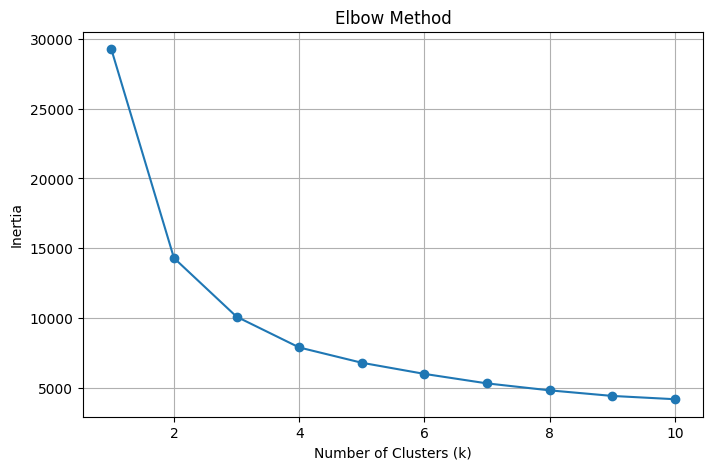

In [10]:
from sklearn.cluster import KMeans

inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pca_df)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

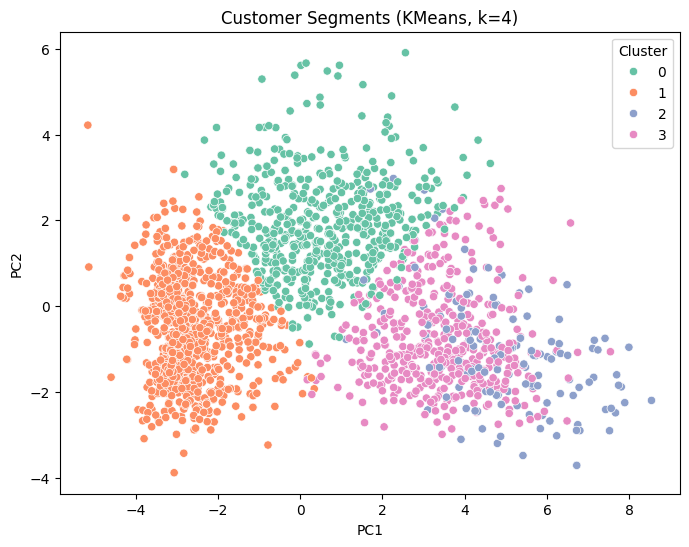

,count
Cluster,
1,1013
0,585
3,469
2,145


In [11]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(pca_df)
pca_df['Cluster'] = df['Cluster'].values

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set2')
plt.title('Customer Segments (KMeans, k=4)')
plt.show()

df['Cluster'].value_counts()

In [12]:
cluster_summary = df.groupby('Cluster')[['Income','Total_Spending','Total_Purchases',
                                           'Age','Total_Children','Recency',
                                           'NumWebVisitsMonth','Response']].mean().round(2)
cluster_summary

,Income,Total_Spending,Total_Purchases,Age,Total_Children,Recency,NumWebVisitsMonth,Response
Cluster,,,,,,,,
0,57273.48,714.19,21.01,59.37,1.24,48.36,5.88,0.12
1,34755.26,95.03,7.78,52.32,1.22,49.13,6.43,0.09
2,80914.06,1636.45,21.06,53.14,0.17,44.04,3.43,0.77
3,73535.81,1262.11,20.72,56.32,0.24,51.14,2.80,0.13


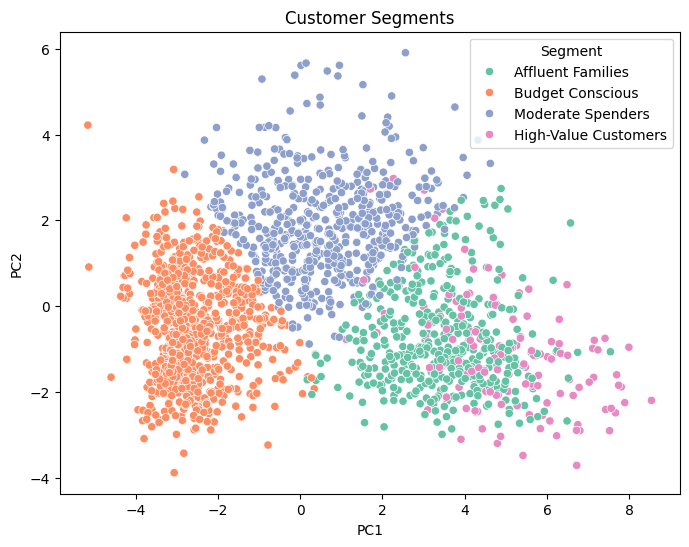

,count
Segment,
Budget Conscious,1013
Moderate Spenders,585
Affluent Families,469
High-Value Customers,145


In [13]:
cluster_names = {
    0: 'Moderate Spenders',
    1: 'Budget Conscious',
    2: 'High-Value Customers',
    3: 'Affluent Families'
}
df['Segment'] = df['Cluster'].map(cluster_names)

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df.assign(Segment=df['Segment'].values),
                x='PC1', y='PC2', hue='Segment', palette='Set2')
plt.title('Customer Segments')
plt.show()

df['Segment'].value_counts()

In [14]:
from sklearn.metrics import silhouette_score

sil_kmeans = silhouette_score(pca_df[['PC1','PC2','PC3']], df['Cluster'])
print("K-Means Silhouette Score:", sil_kmeans)

K-Means Silhouette Score: 0.43260636242648887


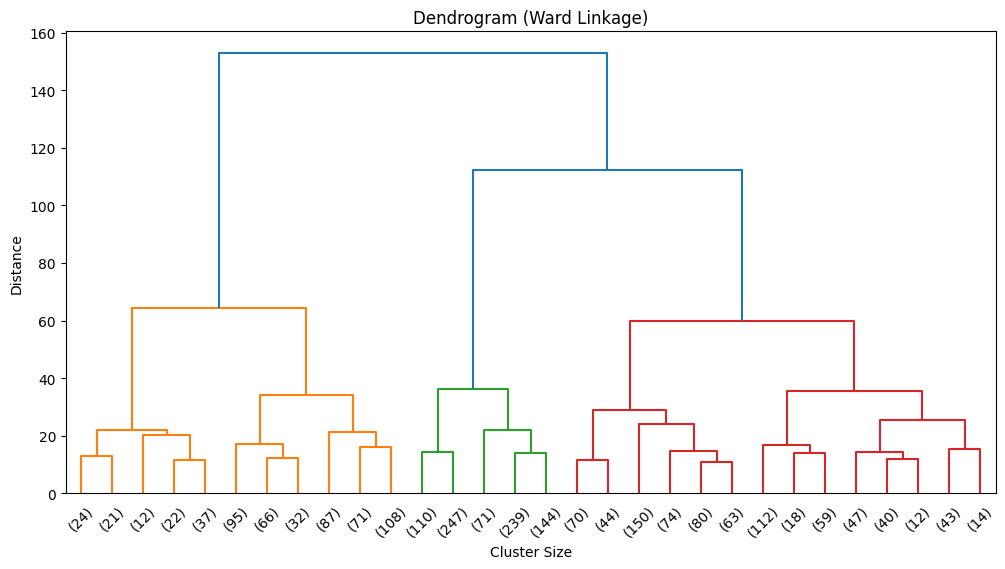

In [15]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(pca_df[['PC1','PC2','PC3']], method='ward')

plt.figure(figsize=(12,6))
dendrogram(linked, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.title('Dendrogram (Ward Linkage)')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.show()

Hierarchical Silhouette Score: 0.36401228032201494


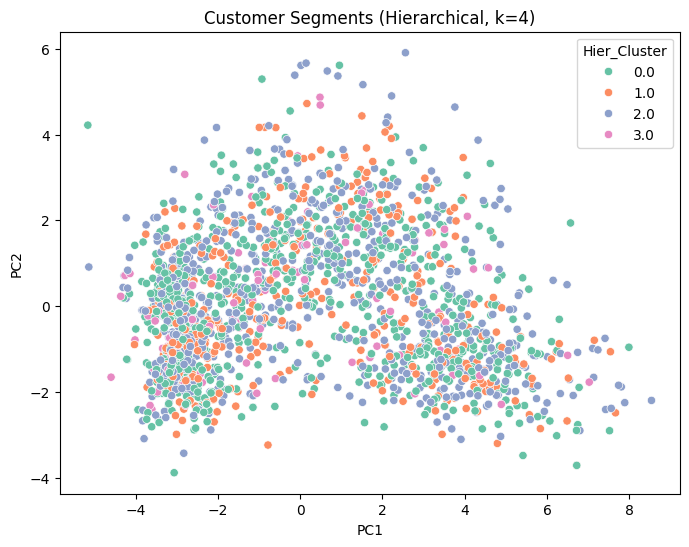

In [16]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
df['Hier_Cluster'] = agg.fit_predict(pca_df[['PC1','PC2','PC3']])

sil_hier = silhouette_score(pca_df[['PC1','PC2','PC3']], df['Hier_Cluster'])
print("Hierarchical Silhouette Score:", sil_hier)

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=df['Hier_Cluster'], palette='Set2')
plt.title('Customer Segments (Hierarchical, k=4)')
plt.show()

In [19]:
comparison = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical (Agglomerative)'],
    'Silhouette Score': [sil_kmeans, sil_hier]
})
print(comparison)

                      Algorithm  Silhouette Score
0                       K-Means          0.432606
1  Hierarchical (Agglomerative)          0.364012


In [20]:
df = df.drop(columns=['Hier_Cluster'], errors='ignore')
df.to_csv('customer_segments_final.csv', index=False)

print("Final dataset saved successfully!")

Final dataset saved successfully!
